In [64]:
import pandas as pd
import numpy as num_paths
import matplotlib.pyplot as psnrResault
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt

In [65]:
df=pd.read_csv("data09102024.csv")

In [66]:
df=pd.DataFrame(df)
df.head()

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,kayip,kayip_orani,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server
0,h13,204.792,0.0,31,2,10000000,36.507699,0.996039,24.022245,67209812,...,-161196,0.000000,4776,39462,44238.0,5072.0,39251.0,44323.0,3.0,h10
1,h1,336.581,0.0,78,3,10000000,35.079593,0.994246,22.400471,67209812,...,-161196,0.000000,962710,44650,1051598.0,5072.0,40267.0,89662.0,3.0,h14
2,h2,260.959,0.0,72,3,10000000,36.081554,0.994275,22.422055,67209812,...,100948,0.390038,3095346,57173,4204117.0,983906.0,47582.0,1121150.0,3.0,h14
3,h3,239.227,0.0,52,2,10000000,29.715019,0.982092,17.469591,67209812,...,1149524,1.950191,5181362,67595,9453074.0,4075282.0,62326.0,5258758.0,3.0,h14
4,h4,409.193,0.0,81,3,10000000,35.194807,0.993585,21.927812,67209812,...,100948,0.390038,7274784,84244,16812102.0,9233590.0,87819.0,14580167.0,3.0,h10


In [67]:
df["mos"]=6
df.shape[0]
for i in range(0,df.shape[0],1):
    if df.ssim_first[i]>=0.99:
        df.mos[i]=5
    elif df.ssim_first[i]>=0.95 and df.ssim_first[i]<0.99:
        df.mos[i]=4
    elif df.ssim_first[i]>=0.88 and df.ssim_first[i]<0.95:
        df.mos[i]=3
    elif df.ssim_first[i]>=0.5 and df.ssim_first[i]<0.88:
        df.mos[i]=2
    elif df.ssim_first[i]<0.5:
        df.mos[i]=1

df

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,kayip_orani,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server,mos
0,h13,204.792,0.0,31,2,10000000,36.507699,0.996039,24.022245,67209812,...,0.000000,4776,39462,4.423800e+04,5072.0,39251.0,4.432300e+04,3.0,h10,5
1,h1,336.581,0.0,78,3,10000000,35.079593,0.994246,22.400471,67209812,...,0.000000,962710,44650,1.051598e+06,5072.0,40267.0,8.966200e+04,3.0,h14,5
2,h2,260.959,0.0,72,3,10000000,36.081554,0.994275,22.422055,67209812,...,0.390038,3095346,57173,4.204117e+06,983906.0,47582.0,1.121150e+06,3.0,h14,5
3,h3,239.227,0.0,52,2,10000000,29.715019,0.982092,17.469591,67209812,...,1.950191,5181362,67595,9.453074e+06,4075282.0,62326.0,5.258758e+06,3.0,h14,4
4,h4,409.193,0.0,81,3,10000000,35.194807,0.993585,21.927812,67209812,...,0.390038,7274784,84244,1.681210e+07,9233590.0,87819.0,1.458017e+07,3.0,h10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,h2,313.056,0.0,93,4,10000000,15.997397,0.743165,5.903466,67209812,...,35.103446,145148612,1511787,9.567170e+08,153118830.0,1597934.0,9.246500e+08,3.0,h10,2
589,h3,308.388,0.0,86,4,10000000,16.057587,0.733531,5.743539,67209812,...,37.833714,160788080,1632081,1.119137e+09,172640846.0,1740744.0,1.099032e+09,3.0,h10,2
590,h4,261.973,0.0,65,3,10000000,15.955686,0.722000,5.559557,67209812,...,41.734097,177710578,1772107,1.298620e+09,192272300.0,1890806.0,1.293195e+09,3.0,h10,2
591,h5,309.301,0.0,84,4,10000000,15.830010,0.712953,5.420477,67209812,...,44.854403,196322902,1911681,1.496854e+09,211869558.0,2048238.0,1.507112e+09,3.0,h10,2


In [68]:
df.dropna(inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,588.0,6.151730e+02,4.232686e+02,1.519770e+02,2.734425e+02,3.889160e+02,1.098511e+03,1.955956e+03
packetLoss,588.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
latency,588.0,7.927551e+01,3.047347e+01,2.000000e+00,5.700000e+01,7.800000e+01,9.925000e+01,1.900000e+02
hopCount,588.0,2.804422e+00,9.325721e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,6.000000e+00
bandwidth,588.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
psnr,588.0,2.305810e+01,6.002657e+00,1.020731e+01,1.783186e+01,2.170569e+01,2.615475e+01,3.702212e+01
ssim_first,588.0,8.999166e-01,8.482664e-02,4.436530e-01,8.317813e-01,9.284065e-01,9.684815e-01,9.961760e-01
ssim_second,588.0,1.217995e+01,5.025604e+00,2.546540e+00,7.741266e+00,1.145146e+01,1.501439e+01,2.417531e+01
kaynak,588.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,588.0,5.810413e+07,8.493663e+06,3.434086e+07,5.138022e+07,5.924454e+07,6.579814e+07,9.358541e+07


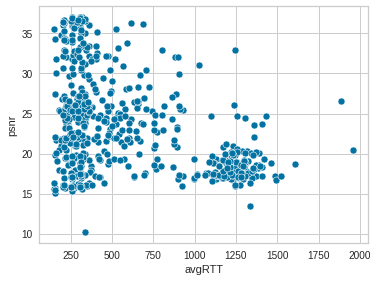

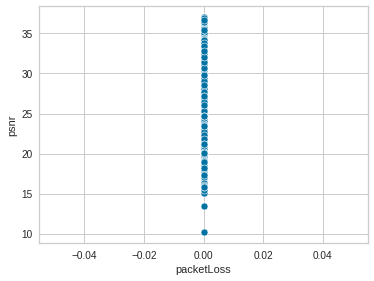

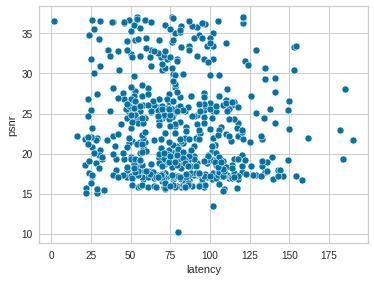

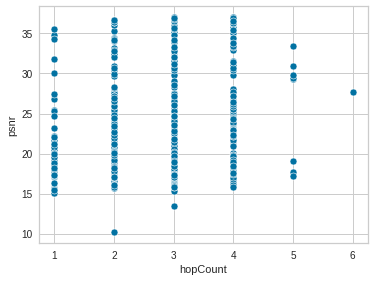

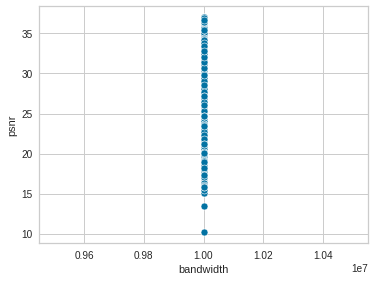

In [69]:
sayisal_veriler=["avgRTT","packetLoss","latency","hopCount","bandwidth"]
for i,deger in enumerate(sayisal_veriler):
    plt.figure(figsize=(20,20))
    ax=plt.subplot(4,3,i+1)
    sns.scatterplot(x=deger,y="psnr",data=df)
    plt.show()

In [70]:
# sns.displot(df)

In [71]:
df["mos"].value_counts()

mos
2    221
4    185
3    126
5     55
1      1
Name: count, dtype: int64

In [72]:
y=df["mos"]
x=df.drop(["mos","host","ssim_first","ssim_second","type","psnr","server","packetLoss","h10gelen","h10giden","h10toplam","h14gelen","h14giden","h14toplam"],axis="columns")
y


0      5
1      5
2      5
3      4
4      5
      ..
588    2
589    2
590    2
591    2
592    2
Name: mos, Length: 588, dtype: int64

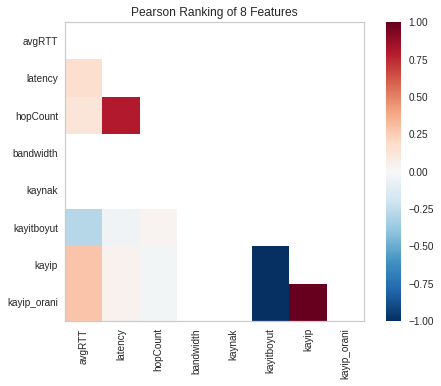

<AxesSubplot:title={'center':'Pearson Ranking of 8 Features'}>

In [73]:
from yellowbrick.features import Rank2D
visualizer=Rank2D(algorithm="pearson")
visualizer.fit(x,y)
visualizer.transform(x)
visualizer.show()

In [74]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,588.0,6.151730e+02,4.232686e+02,1.519770e+02,2.734425e+02,3.889160e+02,1.098511e+03,1.955956e+03
latency,588.0,7.927551e+01,3.047347e+01,2.000000e+00,5.700000e+01,7.800000e+01,9.925000e+01,1.900000e+02
hopCount,588.0,2.804422e+00,9.325721e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,6.000000e+00
bandwidth,588.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
kaynak,588.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,588.0,5.810413e+07,8.493663e+06,3.434086e+07,5.138022e+07,5.924454e+07,6.579814e+07,9.358541e+07
kayip,588.0,9.105684e+06,8.493663e+06,-2.637560e+07,1.411668e+06,7.965268e+06,1.582959e+07,3.286895e+07
kayip_orani,588.0,1.378799e+01,1.263753e+01,-3.900383e+01,2.340230e+00,1.209119e+01,2.379234e+01,4.914482e+01


In [75]:
from sklearn.model_selection import train_test_split
XTrain,XTest,yTrain,yTest=train_test_split(x,y,test_size=0.10, random_state=42)

In [76]:
yTest.value_counts()

mos
2    24
4    21
3    10
5     4
Name: count, dtype: int64

In [77]:
from sklearn.linear_model import LinearRegression
LinModel=LinearRegression()
LinModel.fit(XTrain,yTrain)
tahmin=LinModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

0.7931907665407881


In [78]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.6810635728103611 test: 0.7632513778159458
max_depth : 2 --> score r2 : eğitim:0.8078165368473132 test: 0.8419637497711713
max_depth : 3 --> score r2 : eğitim:0.8622682564530959 test: 0.8906047073657309
max_depth : 4 --> score r2 : eğitim:0.8903665275455885 test: 0.9063010056184885
max_depth : 5 --> score r2 : eğitim:0.9202205801908516 test: 0.9002545604506746
max_depth : 6 --> score r2 : eğitim:0.9400970939943812 test: 0.9014404274315021
max_depth : 7 --> score r2 : eğitim:0.9554613978597941 test: 0.8958132565589066
max_depth : 8 --> score r2 : eğitim:0.9641180310309935 test: 0.9024435430829345
max_depth : 9 --> score r2 : eğitim:0.9706042872481024 test: 0.8966682544959915
max_depth : 10 --> score r2 : eğitim:0.9748245043619718 test: 0.8887868655110925
max_depth : 11 --> score r2 : eğitim:0.9769202925390881 test: 0.8913303236252581
max_depth : 12 --> score r2 : eğitim:0.976486360029576 test: 0.891681381072848
max_depth : 13 --> score r2 : eğitim:0.

In [79]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: 0.7193620593172916
n_neigbors : 2 --> score r2 : eğitim:0.9308670475393913 test: 0.8761891438164522
n_neigbors : 3 --> score r2 : eğitim:0.9030651935391035 test: 0.89361437542747
n_neigbors : 4 --> score r2 : eğitim:0.8928439236860566 test: 0.9050783435926133
n_neigbors : 5 --> score r2 : eğitim:0.8810377994819771 test: 0.9035926133184108
n_neigbors : 6 --> score r2 : eğitim:0.878484588219776 test: 0.9046197848660076
n_neigbors : 7 --> score r2 : eğitim:0.87311213202095 test: 0.8992668136084876
n_neigbors : 8 --> score r2 : eğitim:0.8672257046089198 test: 0.8939869543928372
n_neigbors : 9 --> score r2 : eğitim:0.8625380306470223 test: 0.8883154745866927
n_neigbors : 10 --> score r2 : eğitim:0.8590401400280596 test: 0.8846082820369334
n_neigbors : 11 --> score r2 : eğitim:0.8543692516228352 test: 0.8799409879432264
n_neigbors : 12 --> score r2 : eğitim:0.8558367321090247 test: 0.8792844152210408
n_neigbors : 13 --> score r2 : eğitim:0.85462

In [80]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.6503376166561121 test: 0.7353119382184536
max_depth : 2 --> score r2 : eğitim:0.7952085045168743 test: 0.8257134666197977
max_depth : 3 --> score r2 : eğitim:0.8437643822537906 test: 0.8579398104334164
max_depth : 4 --> score r2 : eğitim:0.8728211421252867 test: 0.8696783722329928
max_depth : 5 --> score r2 : eğitim:0.9040374260968721 test: 0.8745378479805903
max_depth : 6 --> score r2 : eğitim:0.937321778332835 test: 0.8639350296107104
max_depth : 7 --> score r2 : eğitim:0.9544181420810695 test: 0.8156138362846165
max_depth : 8 --> score r2 : eğitim:0.9712807019658781 test: 0.8154594942518872
max_depth : 9 --> score r2 : eğitim:0.9783311297169778 test: 0.8231987549957027
max_depth : 10 --> score r2 : eğitim:0.9827219082584802 test: 0.8228735517527972
max_depth : 11 --> score r2 : eğitim:0.987728104475656 test: 0.8191123391158366
max_depth : 12 --> score r2 : eğitim:0.9908813883492817 test: 0.82376059607453
max_depth : 13 --> score r2 : eğitim:0.99

In [81]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.8582701909397853 test: 0.8549237211860928
max_depth : 2 --> score r2 : eğitim:0.9017167958564846 test: 0.878166006262092
max_depth : 3 --> score r2 : eğitim:0.9406412353971878 test: 0.8844407191510162
max_depth : 4 --> score r2 : eğitim:0.9718767875754359 test: 0.8752927692120664
max_depth : 5 --> score r2 : eğitim:0.9902680013836391 test: 0.8682116149782841
max_depth : 6 --> score r2 : eğitim:0.9977774666189143 test: 0.8236455118120283
max_depth : 7 --> score r2 : eğitim:0.9998483427846281 test: 0.8267884021962498
max_depth : 8 --> score r2 : eğitim:0.9999738058712997 test: 0.8022648598122291
max_depth : 9 --> score r2 : eğitim:0.9999989199723699 test: 0.8135889167584479


In [82]:
from xgboost import XGBRegressor
xgb=XGBRegressor()
xgb.fit(XTrain,yTrain)
tahminXGB=xgb.predict(XTest)
print(r2_score(yTest,tahminXGB))

0.8023035970214777


In [83]:
from sklearn.linear_model import RANSACRegressor
ransac=RandomForestRegressor(random_state=42)
ransac.fit(XTrain,yTrain)
tahminRansac=ransac.predict(XTest)
print(f"ransac -> {r2_score(yTest,tahminRansac)}")

ransac -> 0.8934698377168439


In [84]:
from sklearn.ensemble import ExtraTreesRegressor
for i in range(1,10,1):
    exTree=ExtraTreesRegressor(max_depth=i)
    exTree.fit(XTrain,yTrain)
    tahminExTree=exTree.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminExTree)}")

max_depth : 1 --> score r2 : eğitim:0.5985797737304679 test: 0.6152011129291218
max_depth : 2 --> score r2 : eğitim:0.7559669896718793 test: 0.7832945701729042
max_depth : 3 --> score r2 : eğitim:0.8155718798087799 test: 0.848175804104494
max_depth : 4 --> score r2 : eğitim:0.8566982489984505 test: 0.8828227020523328
max_depth : 5 --> score r2 : eğitim:0.8820211368804973 test: 0.900556315139816
max_depth : 6 --> score r2 : eğitim:0.9004083093060158 test: 0.9102122612408251
max_depth : 7 --> score r2 : eğitim:0.9273473251118796 test: 0.918188332132135
max_depth : 8 --> score r2 : eğitim:0.9442755987568903 test: 0.9132543535560909
max_depth : 9 --> score r2 : eğitim:0.9624368398009465 test: 0.8861558228331935


In [22]:
tahminGbr

array([4.97570325, 2.9982479 , 4.00331443, 2.999985  , 2.00004604,
       4.91423003, 4.60198309, 3.99978812, 4.01556359, 3.58588731,
       3.99915427, 3.99999621, 2.00005317, 4.00745657, 3.99539192,
       3.80622316, 3.56809581, 2.00009994, 2.9997177 , 2.00038972,
       3.94881316, 4.73244577, 1.9999897 , 3.00059004, 4.04659529,
       2.999985  , 4.00026456, 3.63870621, 5.0008316 , 4.00507964,
       3.00008968, 2.0098857 , 2.22994951, 4.00346639, 4.93715303,
       2.00005317, 2.00005763, 2.00001926, 2.82395717, 3.00042866,
       3.43675698, 4.01278052, 2.00005317])

In [23]:
yTest

145    5
282    3
175    4
375    3
423    2
73     5
132    5
137    4
30     4
72     4
70     4
94     4
318    2
90     4
378    4
419    3
9      4
249    2
197    3
233    2
193    4
241    4
352    2
230    3
55     4
358    3
56     3
300    3
274    5
79     3
333    3
116    3
209    3
195    3
342    5
184    2
219    2
39     3
168    3
366    3
75     4
76     4
422    2
Name: mos, dtype: int64

In [26]:
yTrain

289    2
212    3
42     4
17     4
284    2
      ..
188    2
71     3
106    4
272    2
102    4
Name: mos, Length: 275, dtype: int64

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
XTrain[sayisal_veriler]=scaler.fit_transform(XTrain[sayisal_veriler])
XTest[sayisal_veriler]=scaler.transform(XTest[sayisal_veriler])

KeyError: "['packetLoss'] not in index"

In [ ]:
from sklearn.linear_model import LinearRegression
LogModel=LinearRegression()
LogModel.fit(XTrain,yTrain)
tahmin=LogModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

-4.642549972693122


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: -71.4195313685805
n_neigbors : 2 --> score r2 : eğitim:0.5408173794694464 test: -30.180746540462962
n_neigbors : 3 --> score r2 : eğitim:0.38098304140622574 test: -12.35957091007418
n_neigbors : 4 --> score r2 : eğitim:0.3281552469486244 test: -9.492854763586301
n_neigbors : 5 --> score r2 : eğitim:0.2724046958868013 test: -7.497837930339246
n_neigbors : 6 --> score r2 : eğitim:0.23108394497407914 test: -4.9427443097501085
n_neigbors : 7 --> score r2 : eğitim:0.19209244775566126 test: -3.456755754337749
n_neigbors : 8 --> score r2 : eğitim:0.17602631125580537 test: -2.5576503781062625
n_neigbors : 9 --> score r2 : eğitim:0.1710088829317742 test: -1.8517249772630833
n_neigbors : 10 --> score r2 : eğitim:0.161902013384302 test: -1.29895426405142
n_neigbors : 11 --> score r2 : eğitim:0.15543368650474965 test: -0.9510317016514858
n_neigbors : 12 --> score r2 : eğitim:0.1437638012141057 test: -0.7309591890051519
n_neigbors : 13 --> score r2 : e

In [ ]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,bootstrap=True,criterion="friedman_mse",max_features='log2',max_leaf_nodes=None,n_estimators=100,n_jobs=1,random_state=42)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.11064440698553679 test: -0.9106493394064936
max_depth : 2 --> score r2 : eğitim:0.3096475043477387 test: -2.5628808061754627
max_depth : 3 --> score r2 : eğitim:0.519910586117451 test: -4.368034996632447
max_depth : 4 --> score r2 : eğitim:0.6688130935161649 test: -9.106353582307468
max_depth : 5 --> score r2 : eğitim:0.7728111715877166 test: -8.516749120595469
max_depth : 6 --> score r2 : eğitim:0.8164965810486424 test: -7.56924805780395
max_depth : 7 --> score r2 : eğitim:0.8287055299351374 test: -7.168315973295311
max_depth : 8 --> score r2 : eğitim:0.8379512271295804 test: -13.43677374330953
max_depth : 9 --> score r2 : eğitim:0.8404991309431038 test: -10.848339395190308
max_depth : 10 --> score r2 : eğitim:0.8342687130109395 test: -9.247283975873103
max_depth : 11 --> score r2 : eğitim:0.8334497439097873 test: -8.47899860081651
max_depth : 12 --> score r2 : eğitim:0.8336238361783528 test: -9.034320291977089
max_depth : 13 --> score r2 : eğitim

In [ ]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.10061124789406062 test: -0.498523431015212
max_depth : 2 --> score r2 : eğitim:0.19853967411969042 test: -3.4609577066576245
max_depth : 3 --> score r2 : eğitim:0.47647685872718815 test: -34.026308787957454
max_depth : 4 --> score r2 : eğitim:0.7240636388469759 test: -74.40562190798799
max_depth : 5 --> score r2 : eğitim:0.9795529020264285 test: -71.84859497418822
max_depth : 6 --> score r2 : eğitim:0.9833826811387384 test: -72.23760624774027
max_depth : 7 --> score r2 : eğitim:0.987429990338354 test: -71.81432255107657
max_depth : 8 --> score r2 : eğitim:0.9962372899385743 test: -0.8874550010499995
max_depth : 9 --> score r2 : eğitim:0.9985824148972497 test: -72.3241338088478
max_depth : 10 --> score r2 : eğitim:0.9994861256924849 test: -72.25017967653562
max_depth : 11 --> score r2 : eğitim:0.9999807542844047 test: -72.25910849711639
max_depth : 12 --> score r2 : eğitim:0.9999971943186402 test: -72.73617135538156
max_depth : 13 --> score r2 : eği

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.33883339404507307 test: -2.377428860412824
max_depth : 2 --> score r2 : eğitim:0.9562457199999259 test: -17.661178948117293
max_depth : 3 --> score r2 : eğitim:0.987890892239113 test: -23.594518654870196
max_depth : 4 --> score r2 : eğitim:0.9989850375313967 test: -29.953745493628936
max_depth : 5 --> score r2 : eğitim:0.9998685829132781 test: -42.365264581535754
max_depth : 6 --> score r2 : eğitim:0.9999693439964115 test: -49.80191283096458
max_depth : 7 --> score r2 : eğitim:0.9999989030738063 test: -33.286911678722895
max_depth : 8 --> score r2 : eğitim:0.9999998522010303 test: -56.287910237405455
max_depth : 9 --> score r2 : eğitim:0.9999999948824845 test: -58.865711456639865
